# Task 3 — Distributions and relationships
Dataset: `penguins.csv`, 344 penguins across 3 species and 3 islands.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path("data")
CHARTS = Path("charts")
CHARTS.mkdir(exist_ok=True)

# ---- House palette (colour-blind safe, same as the lecture notebook) ----
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
YELLOW, MAGENTA = "#eda100", "#e87ba4"
GREEN, VIOLET, RED = "#008300", "#4a3aa7", "#e34948"
SERIES = [BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED]
INK, INK_SOFT, INK_MUTED = "#0b0b0b", "#52514e", "#8a8985"
GRID, SURFACE, QUIET = "#e6e5e1", "#fcfcfb", "#cfceca"

plt.rcParams.update({
    "figure.figsize": (8, 4.5), "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_SOFT, "axes.titlecolor": INK,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlepad": 14, "axes.labelsize": 10, "axes.spines.top": False,
    "axes.spines.right": False, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": INK_SOFT, "ytick.color": INK_SOFT, "legend.frameon": False,
    "legend.fontsize": 10, "lines.linewidth": 2, "font.size": 11,
    "savefig.dpi": 150, "savefig.bbox": "tight",
})

def save(fig, name):
    fig.savefig(CHARTS / f"{name}.png", facecolor=SURFACE)

def note(ax, text, y=-0.2):
    """Footnote under a chart - used to say what was excluded."""
    ax.text(0, y, text, transform=ax.transAxes, fontsize=9, color=INK_MUTED)

## 0. Find the missing values first, then decide

In [2]:
p = pd.read_csv(DATA / "penguins.csv")
print(p.isna().sum())
print()
print("Rows missing ALL four measurements:")
p[p[["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]].isna().all(axis=1)]

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Rows missing ALL four measurements:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN


Here's what I'm doing about it. Two penguins (one Adelie, one Gentoo) have nothing recorded at all — no measurements, no sex — so they're useless for every chart and I'm dropping them everywhere, 342 left.

The other 11 are missing only `sex`. Their body mass is still a real number, so I keep them for charts 1-3 and only drop them for chart 4, where they obviously can't be placed on a male/female comparison. That chart runs on 333 penguins. Each chart says how many penguins it's actually using.

Not filling anything in — guessing someone's sex or bill length would just be making up data.

In [3]:
meas = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
d = p.dropna(subset=meas).copy()          # 342 penguins - used for charts 1-3
ds = d.dropna(subset=["sex"]).copy()      # 333 penguins - used for chart 4
d["sex"] = d["sex"].str.capitalize(); ds["sex"] = ds["sex"].str.capitalize()
print(len(p), "->", len(d), "(charts 1-3) ->", len(ds), "(chart 4)")

344 -> 342 (charts 1-3) -> 333 (chart 4)


## 1. Distribution of body mass
A histogram: one continuous variable, and the question is about its *shape*.

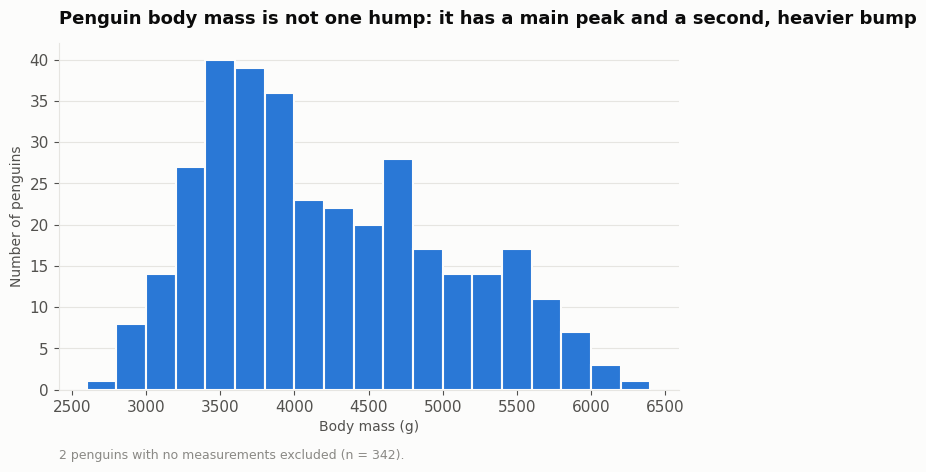

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(d.body_mass_g, bins=np.arange(2600, 6500, 200), color=BLUE, edgecolor=SURFACE, linewidth=1.5, zorder=3)
ax.set_title("Penguin body mass is not one hump: it has a main peak and a second, heavier bump")
ax.title.set_fontsize(12)
ax.set_xlabel("Body mass (g)"); ax.set_ylabel("Number of penguins")
ax.xaxis.grid(False); ax.set_axisbelow(True)
note(ax, "2 penguins with no measurements excluded (n = 342).")
save(fig, "t3_1_mass_hist")
plt.show()

Histogram because body mass is continuous and what I actually want is its shape — where it peaks, whether it's skewed — and a mean alone can't show that.

Looking at it: right-skewed, with a main peak around 3,400-3,800g and a second, flatter bump starting around 4,600g. Definitely not one hump, which means a sentence like "average penguin weighs 4,200g" wouldn't actually describe most real penguins.

## 2. The same distribution, split by species

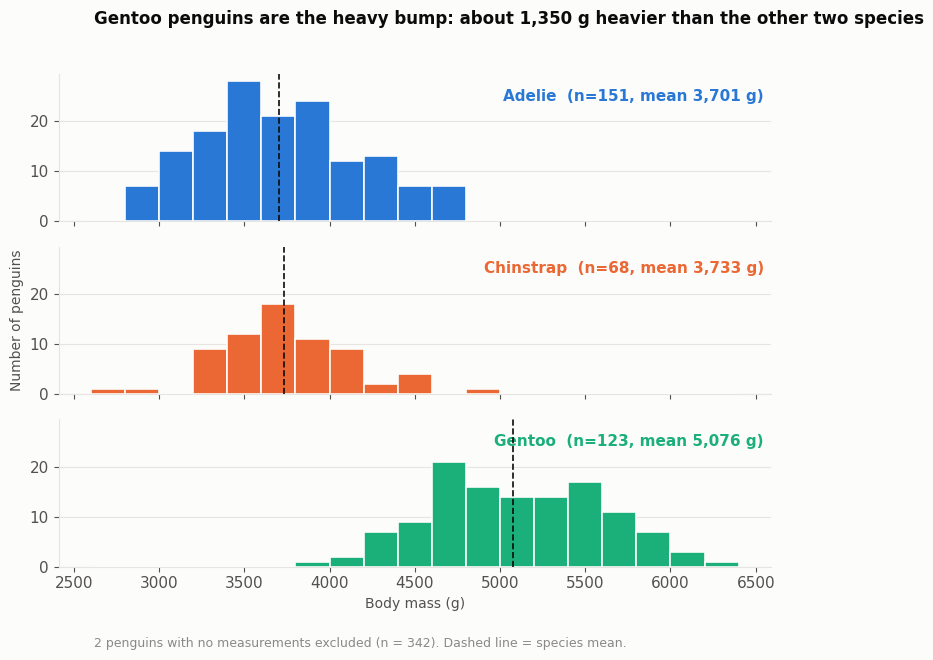

In [5]:
sp_colours = {"Adelie": BLUE, "Chinstrap": ORANGE, "Gentoo": AQUA}
fig, axes = plt.subplots(3, 1, figsize=(8, 6.5), sharex=True, sharey=True)
bins = np.arange(2600, 6500, 200)
for ax, (sp, colour) in zip(axes, sp_colours.items()):
    x = d[d.species == sp].body_mass_g
    ax.hist(x, bins=bins, color=colour, edgecolor=SURFACE, linewidth=1.2, zorder=3)
    ax.axvline(x.mean(), color=INK, linewidth=1.2, linestyle="--", zorder=4)
    ax.text(0.99, 0.82, f"{sp}  (n={len(x)}, mean {x.mean():,.0f} g)", transform=ax.transAxes,
            ha="right", color=colour, fontweight="bold")
    ax.xaxis.grid(False); ax.set_axisbelow(True)
axes[-1].set_xlabel("Body mass (g)")
axes[1].set_ylabel("Number of penguins")
fig.suptitle("Gentoo penguins are the heavy bump: about 1,350 g heavier than the other two species",
             x=0.125, ha="left", fontsize=12, fontweight="bold", color=INK)
fig.tight_layout(rect=[0, 0.03, 1, 0.96])
fig.text(0.125, 0.0, "2 penguins with no measurements excluded (n = 342). Dashed line = species mean.", fontsize=9, color=INK_MUTED)
save(fig, "t3_2_mass_by_species")
plt.show()

Used small multiples on a shared axis rather than overlapping the three histograms, since overlapping would just hide them behind each other. Stacking them lets you compare position directly, and colour here actually means something — it's species, matching the rest of the notebook.

This mostly explains step 1. Adelie (mean ~3,700g) and Chinstrap (~3,733g) land almost on top of each other and make up the main peak, while Gentoo (~5,076g) is the heavy bump on its own. So the "two humps" from before were really just two species groups sitting next to each other. There's still spread within each species though — chart 4 below traces most of that to sex.

## 3. Bill length vs bill depth — Simpson's paradox

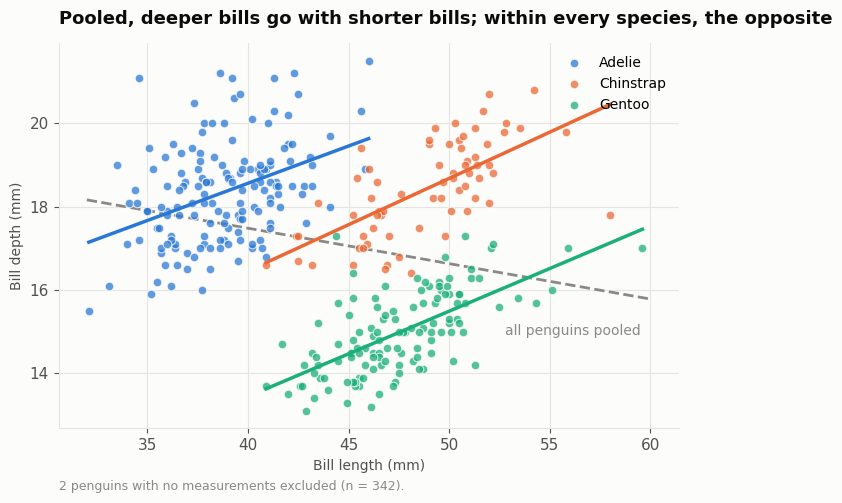

Pooled correlation: -0.24
species
Adelie       0.39
Chinstrap    0.65
Gentoo       0.64
dtype: float64


In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
for sp, colour in sp_colours.items():
    s = d[d.species == sp]
    ax.scatter(s.bill_length_mm, s.bill_depth_mm, s=38, color=colour, alpha=0.75,
               edgecolor=SURFACE, linewidth=0.8, label=sp, zorder=3)
# overall trend across all penguins (grey) vs within-species trends (coloured)
m, b = np.polyfit(d.bill_length_mm, d.bill_depth_mm, 1)
xs = np.array([32, 60]); ax.plot(xs, m * xs + b, color=INK_MUTED, linestyle="--", linewidth=2, zorder=2)
ax.text(59.5, m * 59.5 + b - 0.9, "all penguins pooled", color=INK_MUTED, ha="right", fontsize=10)
for sp, colour in sp_colours.items():
    s = d[d.species == sp]
    m2, b2 = np.polyfit(s.bill_length_mm, s.bill_depth_mm, 1)
    x2 = np.array([s.bill_length_mm.min(), s.bill_length_mm.max()])
    ax.plot(x2, m2 * x2 + b2, color=colour, linewidth=2.5, zorder=4)
ax.set_title("Pooled, deeper bills go with shorter bills; within every species, the opposite")
ax.title.set_fontsize(12)
ax.set_xlabel("Bill length (mm)"); ax.set_ylabel("Bill depth (mm)")
ax.legend(loc="upper right", title=None)
ax.set_axisbelow(True)
note(ax, "2 penguins with no measurements excluded (n = 342).", y=-0.16)
save(fig, "t3_3_simpsons_paradox")
plt.show()

print("Pooled correlation:", round(d.bill_length_mm.corr(d.bill_depth_mm), 2))
print(d.groupby("species").apply(lambda s: round(s.bill_length_mm.corr(s.bill_depth_mm), 2), include_groups=False))

Scatter plot, obviously — two numeric variables, question is whether they move together.

So here's the weird part. Pooled across all 342 penguins the correlation is negative, about -0.24 — longer bills look shallower. But split by species it flips to positive in every single one (Adelie +0.39, Chinstrap +0.65, Gentoo +0.64) — within a species, a longer bill does go with a deeper one. The reversal happens because the species differ from each other in both traits, in the opposite direction from the within-species trend: Gentoo have long, shallow bills as a species, Adelie have short, deep ones. That between-species difference is bigger than the within-species trend, so pooling everyone together points the regression line the wrong way.

That's Simpson's paradox — an aggregate trend reverses once you account for a grouping variable hiding underneath it. Which means: the pooled correlation here answers "how do penguins in general differ from each other", not "does a deeper bill come with a longer bill, in a penguin" — those are different questions, and you need the colour split to even notice they're different.

## 4. Average body mass by species and sex

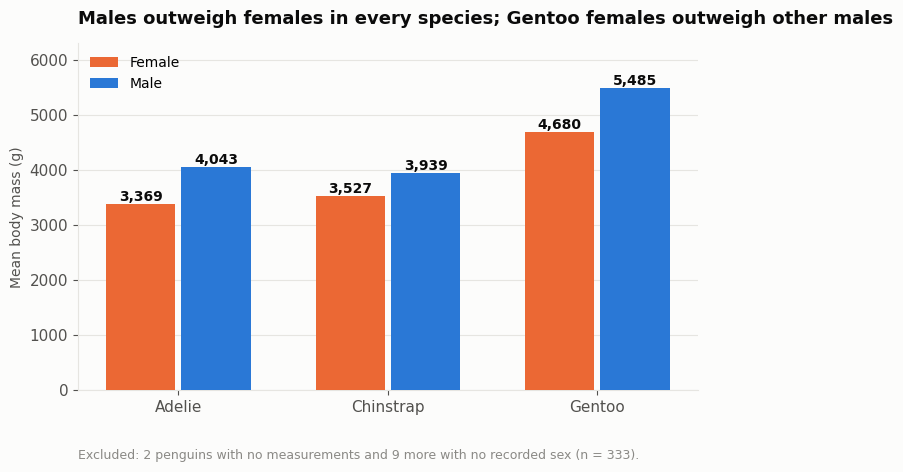

sex,Female,Male
species,,
Adelie,3369.0,4043.0
Chinstrap,3527.0,3939.0
Gentoo,4680.0,5485.0


In [7]:
avg = ds.groupby(["species", "sex"]).body_mass_g.mean().unstack()
species = list(avg.index); x = np.arange(len(species)); w = 0.36

fig, ax = plt.subplots(figsize=(8, 4.5))
for i, (sex, colour) in enumerate(zip(["Female", "Male"], [ORANGE, BLUE])):
    bars = ax.bar(x + (i - 0.5) * w, avg[sex], width=w * 0.92, color=colour, label=sex, zorder=3)
    for bar, v in zip(bars, avg[sex]):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 60, f"{v:,.0f}", ha="center", fontsize=10, fontweight="bold", color=INK)
ax.set_xticks(x); ax.set_xticklabels(species)
ax.set_ylim(0, 6300)
ax.set_title("Males outweigh females in every species; Gentoo females outweigh other males")
ax.title.set_fontsize(12)
ax.set_ylabel("Mean body mass (g)")
ax.xaxis.grid(False); ax.set_axisbelow(True); ax.legend(loc="upper left")
note(ax, "Excluded: 2 penguins with no measurements and 9 more with no recorded sex (n = 333).")
save(fig, "t3_4_mass_species_sex")
plt.show()
avg.round(0)

Grouped bar, since it's an average across two categories at once (species and sex), and bars start at zero because length is the value here. Grouped by species so the male/female pair sits side by side within each — that's the comparison I actually care about.

Males come out heavier in every species, by roughly 400-800g (Adelie ~670g, Chinstrap ~410g, Gentoo ~800g). Interesting side note: Gentoo females (~4,680g) outweigh the males of both other species (~4,040g and ~3,940g). So sex explains a lot of the spread inside a species, while species is what explains the big gap from chart 1.

One caveat — these are just means, chart 2 shows individuals within a species still overlap a fair amount.